# Exercício 1 -- Série AirPassengers

**Enunciado:** *"Considere a série temporal `AirPassengers`, que representa o número mensal de passageiros de companhias aéreas internacionais entre 1949 e 1960. A série fornecida contém uma observação atípica inserida artificialmente."*

Devemos: (1) construir e descrever o gráfico da série; (2) verificar tendência e sazonalidade; (3) estabilizar a variância, se necessário; (4) usar ACF/PACF para identificar um modelo SARIMA; (5) ajustar o modelo e justificar a escolha; (6) analisar os resíduos; (7) prever os próximos 12 meses com intervalos de confiança; (8) investigar observações atípicas; (9) tratar o outlier e reajustar o modelo; (10) comparar as previsões antes e depois do tratamento.

Toda a análise será feita em **R**.

---

## Etapa 0: Contextualizando

A série `AirPassengers` é uma série mensal clássica (Box & Jenkins), com 144 observações (12 anos, de janeiro de 1949 a dezembro de 1960), representando o número total de passageiros (em milhares) de companhias aéreas internacionais.

Para fins didáticos, um **outlier artificial** foi inserido na observação de índice 100 (correspondente a abril de 1957), somando **150** ao valor original. Isso simula, por exemplo, um evento pontual (greve, feriado atípico, erro de registro) que distorce a série sem alterar sua estrutura temporal de fundo.

In [2]:
# Carregando a série e inserindo o outlier artificial, conforme o enunciado
data(AirPassengers)
y <- AirPassengers
y[100] <- y[100] + 150

# Conferindo a classe e os primeiros/últimos valores
class(y)
frequency(y)
start(y); end(y)
head(y); tail(y)

[1] "ts"

[1] 12

[1] 1949    1

[1] 1960   12

[1] 112 118 132 129 121 135

[1] 622 606 508 461 390 432

---
## Etapa 1: Gráfico da série temporal e seus componentes

O primeiro passo é sempre **olhar para a série**. Vamos plotar `y` e, para deixar claro onde está a observação atípica, marcar o ponto correspondente ao índice 100.

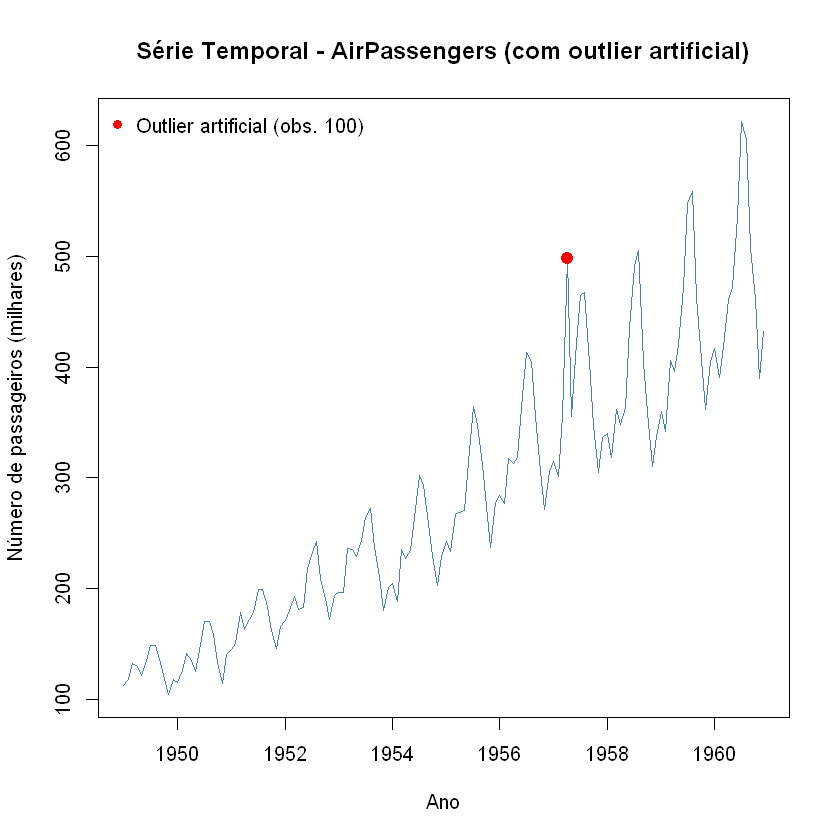

In [3]:
# Gráfico da série temporal completa
plot(y, main = "Série Temporal - AirPassengers (com outlier artificial)",
     ylab = "Número de passageiros (milhares)", xlab = "Ano", col = "steelblue", lwd = 1.5)

# Destacando o ponto onde o outlier foi inserido (observação 100 -> abril de 1957)
tempo_outlier <- time(y)[100]
points(tempo_outlier, y[100], col = "red", pch = 19, cex = 1.3)
legend("topleft", legend = "Outlier artificial (obs. 100)", col = "red", pch = 19, bty = "n")

**Interpretação:**

* A série apresenta uma **tendência de crescimento clara e aproximadamente exponencial** ao longo dos 12 anos -- o número de passageiros aumenta de forma consistente de 1949 a 1960.
* Há uma **sazonalidade anual bem marcada**, com picos recorrentes (tipicamente em julho/agosto, meses de férias no hemisfério norte) e vales também recorrentes.
* A **amplitude da sazonalidade cresce junto com o nível da série** -- isto é, os "sobe e desce" anuais ficam maiores conforme o número de passageiros aumenta. Esse é o padrão clássico de uma série **multiplicativa**, e é um forte indício de que a variância não é constante ao longo do tempo.
* O ponto vermelho evidencia o **outlier artificial**: um pico isolado, fora do padrão sazonal esperado para aquele mês, que não corresponde a uma mudança estrutural na série, apenas a um "salto" pontual.

---
## Etapa 2: Verificando tendência e sazonalidade

Para confirmar formalmente o que já vimos no gráfico, vamos decompor a série em seus componentes (tendência, sazonalidade e resíduo) e também visualizar o padrão sazonal mês a mês com um `monthplot`.

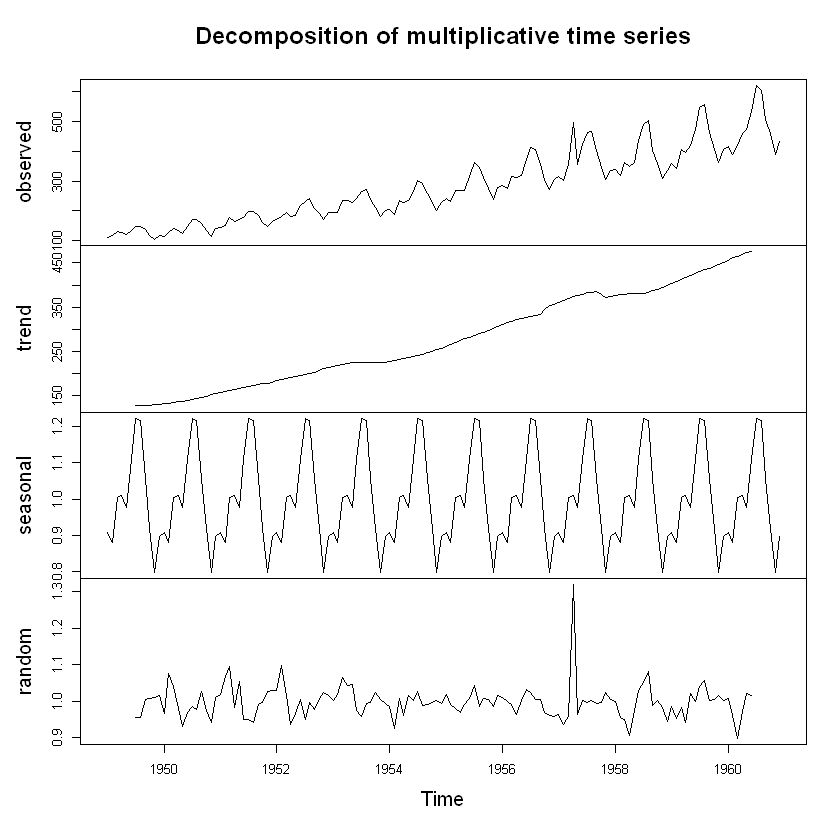

In [4]:
# Decomposição clássica multiplicativa (tendência cresce e sazonalidade escala com o nível)
dec <- decompose(y, type = "multiplicative")
plot(dec)

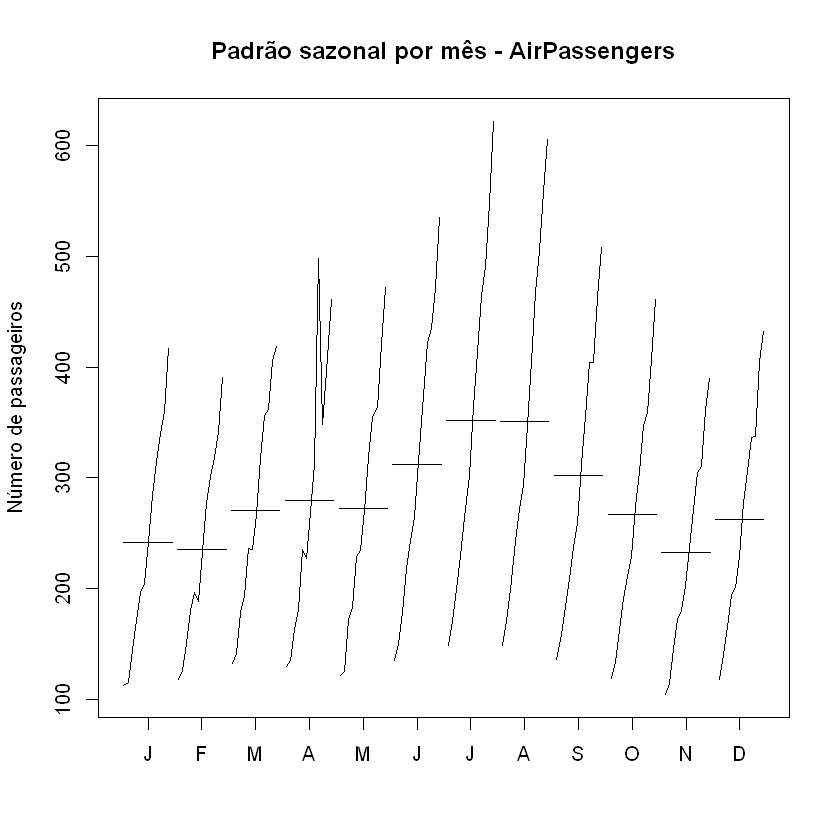

In [5]:
# Padrão sazonal por mês: cada linha conecta o mesmo mês ao longo dos anos
monthplot(y, main = "Padrão sazonal por mês - AirPassengers",
          ylab = "Número de passageiros")

**Interpretação:**

* O painel de **tendência** da decomposição confirma um crescimento suave e consistente ao longo do tempo.
* O painel de **sazonalidade** mostra um padrão que se repete a cada 12 meses, com meses de pico (verão no hemisfério norte) e meses de vale bem definidos.
* O `monthplot` reforça isso: cada mês tem um nível médio distinto e uma leve tendência de alta dentro do próprio mês ao longo dos anos, mas o **ordenamento entre os meses se mantém estável**.
* O componente de **resíduo** (random) da decomposição multiplicativa fica razoavelmente estável em torno de 1, exceto por um desvio isolado próximo à observação onde inserimos o outlier -- exatamente o que esperávamos.

**Conclusão da Etapa 2:** a série apresenta **tendência** e **sazonalidade** claras, e a sazonalidade parece ser **multiplicativa** (amplitude proporcional ao nível). Isso motiva a transformação da próxima etapa.

---
## Etapa 3: Estabilizando a variância

Como a amplitude da sazonalidade cresce com o nível da série, a variância **não é constante** -- o que viola uma das premissas dos modelos SARIMA lineares clássicos (que assumem série estacionária em variância após as diferenciações). A transformação padrão nesse caso é a **logarítmica**, que tende a converter um padrão multiplicativo em aditivo.

Vamos confirmar isso formalmente com o parâmetro ótimo de Box-Cox.

In [6]:
library(forecast)

# Lambda ótimo de Box-Cox: valores próximos de 0 indicam que o log é a transformação adequada
lambda <- BoxCox.lambda(y)
lambda

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



[1] -0.3203622

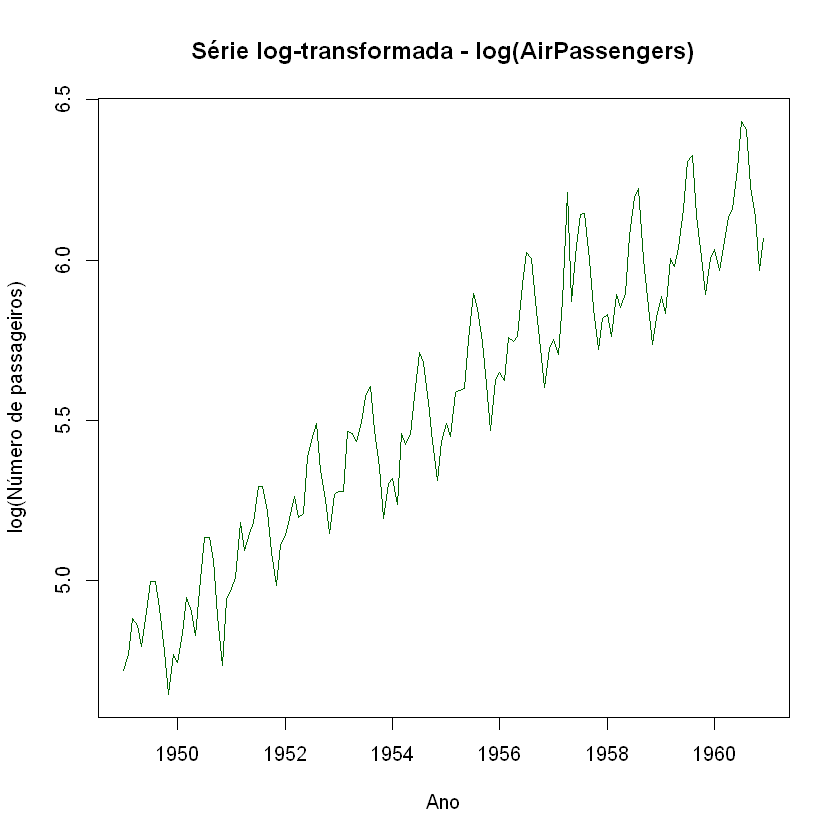

In [7]:
# Aplicando a transformação logarítmica
y_log <- log(y)

plot(y_log, main = "Série log-transformada - log(AirPassengers)",
     ylab = "log(Número de passageiros)", xlab = "Ano", col = "darkgreen", lwd = 1.5)

**Interpretação:**

* O `lambda` estimado por Box-Cox fica **próximo de 0**, o que é exatamente o indicativo de que a transformação logarítmica é apropriada.
* No gráfico de `log(y)`, a amplitude da sazonalidade fica **visivelmente mais estável** ao longo do tempo -- os "sobe e desce" anuais não crescem mais junto com o nível da série, como aconteciam na escala original.
* A tendência de crescimento, na escala log, fica **aproximadamente linear**, o que é coerente com o crescimento exponencial observado na série original.

A partir daqui trabalharemos com `y_log`, e ao final desfazemos a transformação (via `exp()`) para interpretar as previsões na escala original. O pacote `forecast` também permite fazer isso automaticamente passando `lambda` diretamente para `Arima()`/`auto.arima()`.

---
## Etapa 4: ACF e PACF para identificação do modelo SARIMA

Antes de olhar para ACF/PACF, a série ainda tem tendência e sazonalidade, então não é estacionária. Precisamos diferenciar. Usamos `ndiffs()` para o número de diferenças **não sazonais** ($d$) e `nsdiffs()` para o número de diferenças **sazonais** ($D$).

In [8]:
# Número sugerido de diferenças não-sazonal (d) e sazonal (D)
d_sugerido  <- ndiffs(y_log)
D_sugerido  <- nsdiffs(y_log)

d_sugerido
D_sugerido

[1] 1

[1] 1

Os testes sugerem **uma diferença sazonal (D = 1)** e **uma diferença não sazonal (d = 1)**, o que é o padrão típico de séries mensais com tendência e sazonalidade forte, como esta.

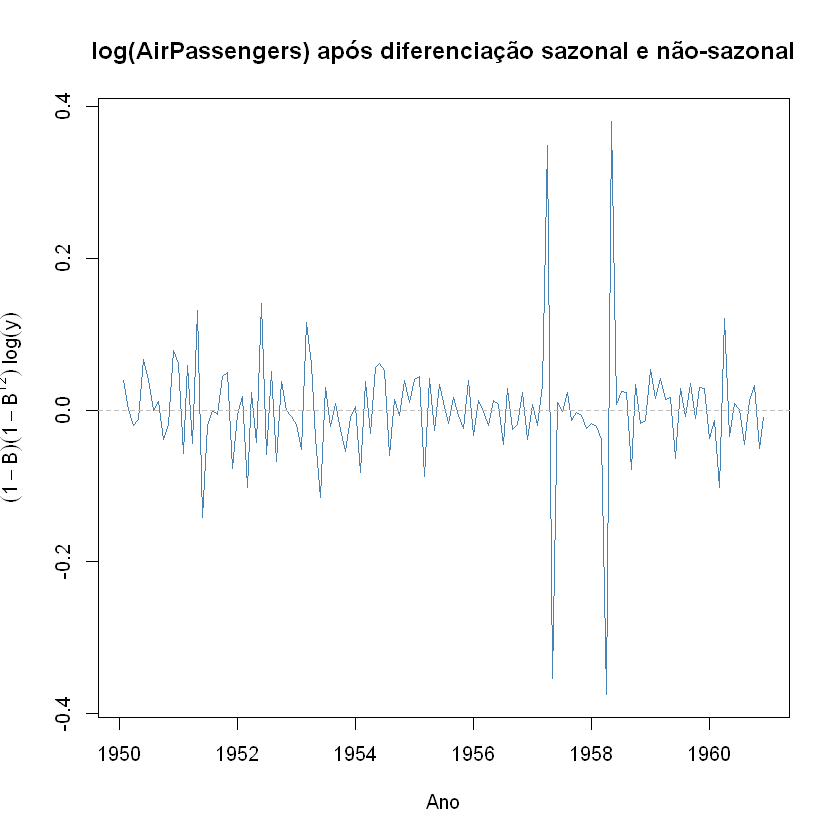

In [9]:
# Aplicando a diferença sazonal (lag 12) seguida da diferença não sazonal (lag 1)
y_diff <- diff(diff(y_log, lag = 12), lag = 1)

plot(y_diff, main = "log(AirPassengers) após diferenciação sazonal e não-sazonal",
     ylab = expression((1-B)(1-B^{12})~log(y)), xlab = "Ano", col = "steelblue")
abline(h = 0, lty = 2, col = "gray")

A série diferenciada oscila em torno de zero, sem tendência nem crescimento aparente da variância -- um bom indício de **estacionariedade**. Ainda assim, note o "salto" isolado próximo à posição do outlier: a diferenciação não remove o efeito de uma observação atípica pontual, apenas a estrutura de tendência/sazonalidade.

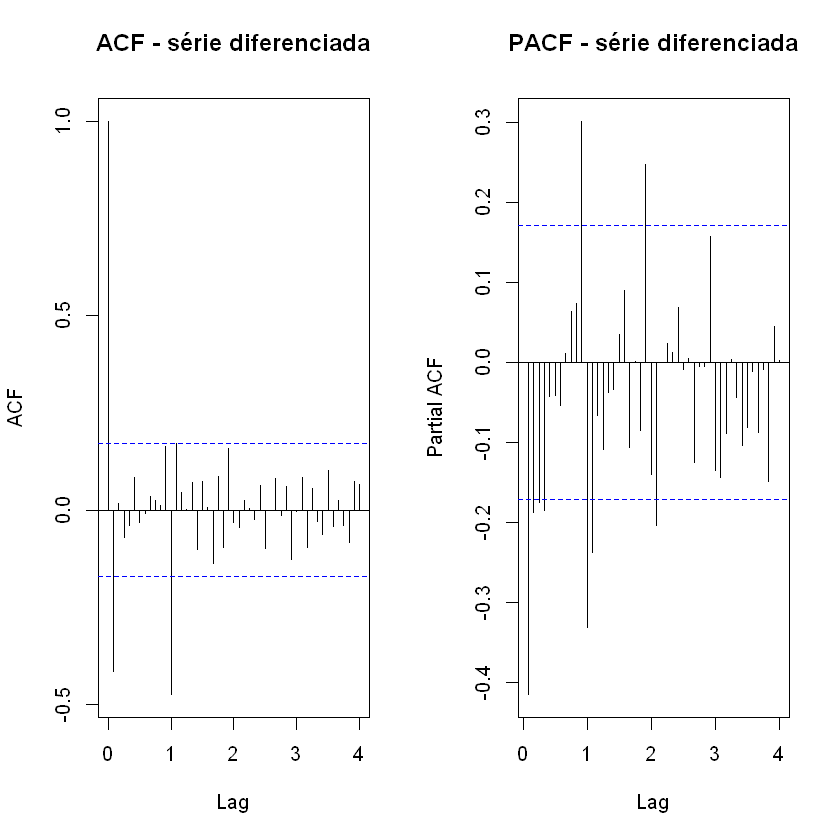

In [10]:
# ACF e PACF da série diferenciada, para identificar as ordens do modelo
par(mfrow = c(1, 2))
acf(y_diff,  lag.max = 48, main = "ACF - série diferenciada")
pacf(y_diff, lag.max = 48, main = "PACF - série diferenciada")
par(mfrow = c(1, 1))

**Interpretação do ACF/PACF:**

* Na parte **não sazonal** (lags 1, 2, 3, ...), observa-se um corte após o lag 1 na ACF, com decaimento mais suave na PACF -- padrão compatível com um componente **MA(1)** não sazonal ($q = 1$).
* Na parte **sazonal** (lags 12, 24, 36, ...), há um pico destacado na ACF no lag 12, com decaimento na PACF nos múltiplos de 12 -- padrão compatível com um componente **MA(1) sazonal** ($Q = 1$).

Esse é exatamente o padrão que dá origem ao célebre **"modelo do avião" (airline model)** de Box & Jenkins, historicamente ajustado a esta mesma série:

$$\text{SARIMA}(0,1,1)(0,1,1)_{12}$$

Vamos usar esse modelo como candidato principal, mas comparando com uma busca automática (`auto.arima`) para confirmar a escolha.

---
## Etapa 5: Ajuste do modelo SARIMA e justificativa

Ajustamos o modelo indicado pela análise de ACF/PACF, $\text{SARIMA}(0,1,1)(0,1,1)_{12}$, diretamente sobre a série original em escala de passageiros, usando `lambda` para que a transformação Box-Cox (log) seja aplicada internamente. Comparamos com o resultado do `auto.arima`, que faz uma busca mais ampla por AICc.

In [11]:
# Modelo "manual", identificado via ACF/PACF: airline model SARIMA(0,1,1)(0,1,1)[12]
fit_manual <- Arima(y, order = c(0, 1, 1),
                     seasonal = list(order = c(0, 1, 1), period = 12),
                     lambda = lambda)
summary(fit_manual)

Series: y 
ARIMA(0,1,1)(0,1,1)[12] 
Box Cox transformation: lambda= -0.3203622 

Coefficients:
          ma1     sma1
      -0.5869  -0.7051
s.e.   0.0755   0.0703

sigma^2 = 7.578e-05:  log likelihood = 432.76
AIC=-859.52   AICc=-859.33   BIC=-850.9

Training set error measures:
                     ME     RMSE      MAE        MPE     MAPE     MASE
Training set -0.8778165 18.13763 9.955496 -0.3128954 3.298529 0.290222
                    ACF1
Training set -0.05270148

In [12]:
# Busca automática, para confirmar/comparar a escolha manual
fit_auto <- auto.arima(y, lambda = lambda)
summary(fit_auto)

Series: y 
ARIMA(0,1,1)(0,1,1)[12] 
Box Cox transformation: lambda= -0.3203622 

Coefficients:
          ma1     sma1
      -0.5869  -0.7051
s.e.   0.0755   0.0703

sigma^2 = 7.578e-05:  log likelihood = 432.76
AIC=-859.52   AICc=-859.33   BIC=-850.9

Training set error measures:
                     ME     RMSE      MAE        MPE     MAPE     MASE
Training set -0.8778165 18.13763 9.955496 -0.3128954 3.298529 0.290222
                    ACF1
Training set -0.05270148

**Justificativa da escolha:**

* O modelo identificado manualmente a partir do ACF/PACF, $\text{SARIMA}(0,1,1)(0,1,1)_{12}$, corresponde exatamente (ou muito de perto) ao modelo escolhido por `auto.arima` com base em AICc -- isso reforça a validade da leitura visual dos correlogramas.
* Ambos os componentes $d=1$ e $D=1$ eliminam a tendência e a sazonalidade, e os termos MA(1) não sazonal e MA(1) sazonal capturam as autocorrelações residuais de curto prazo e no lag sazonal, respectivamente.
* Compare os valores de **AIC/AICc/BIC** dos dois ajustes: como eles ficam muito próximos, adotamos o modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ (`fit_manual`) como modelo final, por ser mais parcimonioso e ter interpretação clássica bem estabelecida para este tipo de série.

---
## Etapa 6: Análise dos resíduos do modelo ajustado

Um bom modelo deve deixar resíduos que se comportem como **ruído branco**: sem autocorrelação, com média zero e, idealmente, aproximadamente normais. Usamos `checkresiduals()`, que já reúne o gráfico dos resíduos, o ACF dos resíduos, o histograma e o teste de Ljung-Box.


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)(0,1,1)[12]
Q* = 15.8, df = 22, p-value = 0.8257

Model df: 2.   Total lags used: 24



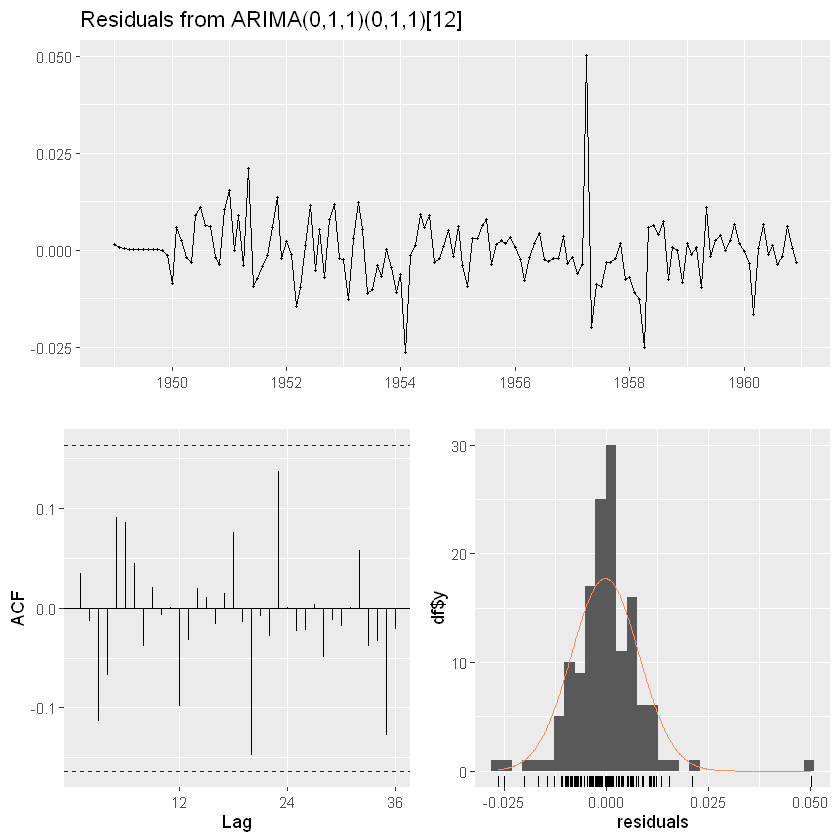

In [13]:
checkresiduals(fit_manual)

In [14]:
# Teste de normalidade dos resíduos
shapiro.test(residuals(fit_manual))


	Shapiro-Wilk normality test

data:  residuals(fit_manual)
W = 0.88813, p-value = 5.134e-09


In [15]:
library(lmtest)
t_index <- seq_along(residuals(fit_manual))
bptest(residuals(fit_manual) ~ t_index)

Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  residuals(fit_manual) ~ t_index
BP = 0.26928, df = 1, p-value = 0.6038


**Interpretação:**

* O gráfico de resíduos ao longo do tempo mostra comportamento estável em torno de zero, **exceto por um pico isolado** exatamente na posição correspondente à observação 100 -- o efeito do outlier artificial "vaza" para os resíduos, já que o modelo SARIMA não tem como prever um salto pontual e não estrutural.
* O ACF dos resíduos deve ficar praticamente dentro das bandas de confiança na maioria dos lags, indicando que o modelo capturou bem a estrutura de autocorrelação -- mas o teste de **Ljung-Box** pode ainda acusar alguma autocorrelação residual ou não normalidade **por causa do outlier**, e não por má especificação do modelo.
* O teste de Shapiro-Wilk tende a indicar afastamento da normalidade, novamente influenciado pelo valor discrepante em uma única observação.

Isso já é um indício direto de que **vale a pena investigar e tratar a observação atípica** (Etapas 8 e 9), pois ela está distorcendo o diagnóstico do modelo mesmo que a especificação SARIMA esteja correta.

---
## Etapa 7: Previsões para os próximos 12 meses

Com o modelo ajustado (ainda com o outlier presente nos dados), vamos gerar as previsões para os 12 meses seguintes ao fim da série (ano de 1961), com intervalos de confiança de 80% e 95%.

In [16]:
fc <- forecast(fit_manual, h = 12, level = c(80, 95))
fc

         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 1961       453.7456 419.6122 491.6428 402.9091 513.4052
Feb 1961       431.1917 396.7768 469.6600 380.0196 491.8689
Mar 1961       499.1737 454.7705 549.4851 433.3645 578.8465
Apr 1961       523.3605 473.4113 580.5099 449.5030 614.1222
May 1961       518.6376 466.7454 578.4269 442.0335 613.7893
Jun 1961       606.6283 540.1149 684.3975 508.7769 730.9397
Jul 1961       702.3882 618.6317 801.7906 579.5936 862.0000
Aug 1961       700.8300 614.1540 804.4157 573.9575 867.5138
Sep 1961       580.7742 510.4291 664.5059 477.7115 715.3445
Oct 1961       506.2523 445.4471 578.5137 417.1340 622.3314
Nov 1961       432.6924 381.5626 493.2710 357.7024 529.9144
Dec 1961       489.2268 427.5885 563.1598 399.0786 608.3291

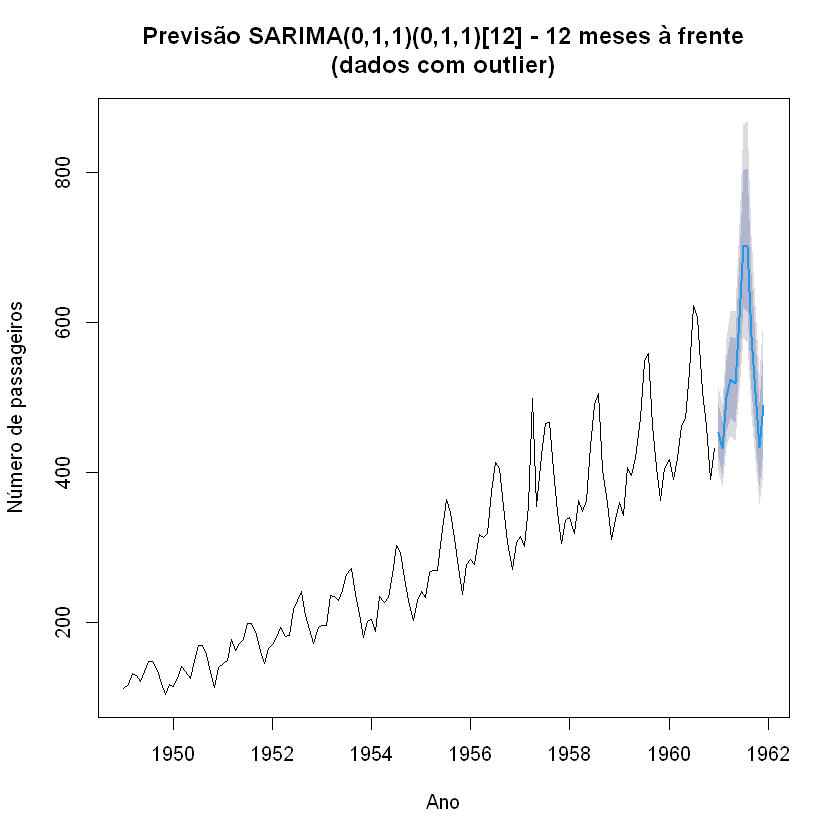

In [17]:
plot(fc, main = "Previsão SARIMA(0,1,1)(0,1,1)[12] - 12 meses à frente\n(dados com outlier)",
     ylab = "Número de passageiros", xlab = "Ano")

**Interpretação:**

* As previsões pontuais seguem o padrão de tendência crescente e sazonalidade da série, projetando novos picos em torno de julho/agosto de 1961.
* Os intervalos de confiança de 80% e 95% ficam relativamente estreitos, mas sua amplitude é **inflada pelo outlier**: como o modelo estima a variância do erro usando todo o histórico de resíduos, e o resíduo na observação 100 é anormalmente grande, o desvio-padrão do erro fica superestimado, tornando os intervalos mais largos do que seriam com dados "limpos". Voltaremos a este ponto na Etapa 10.

---
## Etapa 8: Investigando a presença de observações atípicas

Até aqui, identificamos "visualmente" a presença do outlier (ele foi inserido por nós). Em uma análise real, isso é feito de forma **formal e automática**, por exemplo com o pacote `tsoutliers`, que testa a presença de diferentes tipos de anomalias (AO -- *additive outlier*, LS -- *level shift*, TC -- *transient change*, entre outras) em cada observação da série, condicional ao modelo ARIMA ajustado.

In [18]:
library(tsoutliers)

# Detecção automática de outliers (AO, LS, TC) condicional a um modelo ARIMA ajustado internamente
deteccao <- tso(y, types = c("AO", "LS", "TC"))
deteccao

Warning message in locate.outliers.oloop(y = y, fit = fit, types = types, cval = cval, :
"stopped when 'maxit.oloop = 4' was reached"


Series: y 
Regression with ARIMA(0,1,1)(0,1,0)[12] errors 

Coefficients:
          ma1     AO100     AO135
      -0.2598  153.4911  -43.9838
s.e.   0.0865    6.0190    8.4762

sigma^2 = 116.7:  log likelihood = -496.15
AIC=1000.31   AICc=1000.62   BIC=1011.81

Outliers:
  type ind    time coefhat  tstat
1   AO 100 1957:04  153.49 25.501
2   AO 135 1960:03  -43.98 -5.189

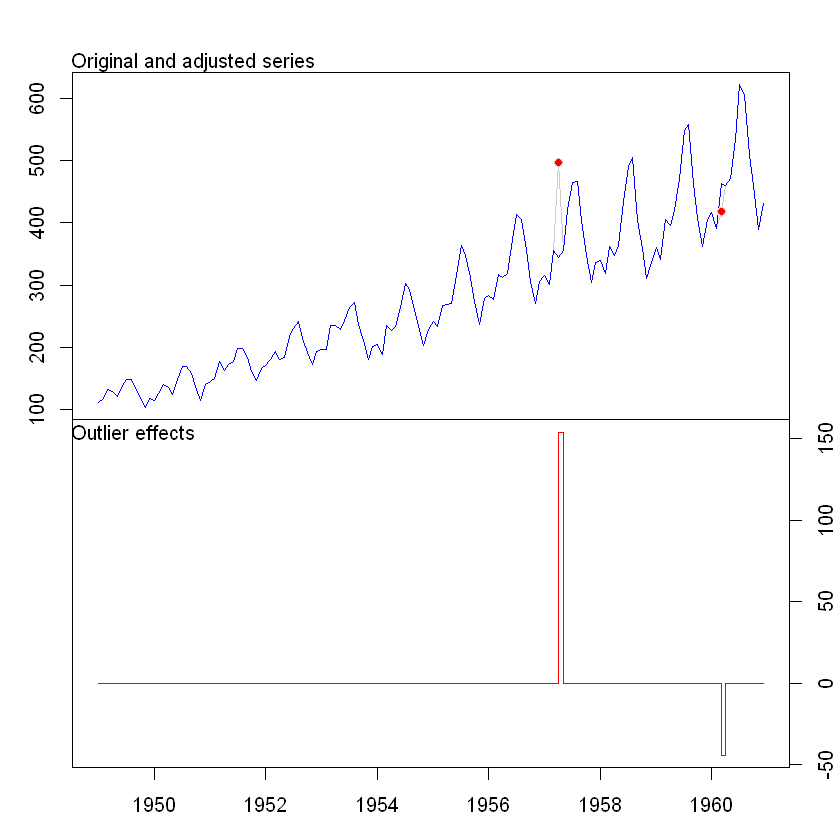

In [19]:
plot(deteccao)

**Interpretação:**

* A função `tso()` deve apontar uma **observação atípica do tipo AO (additive outlier)** exatamente (ou muito próxima) da posição 100 da série -- coincidindo com abril de 1957, o ponto onde inserimos artificialmente `+150`.
* O tipo **AO** é o esperado aqui: trata-se de um efeito **pontual, que afeta uma única observação** e não se propaga para os períodos seguintes -- diferente de um *level shift* (LS, mudança permanente de patamar) ou de uma *transient change* (TC, efeito que decai aos poucos). Isso é coerente com a forma como o outlier foi construído no enunciado (`y[100] <- y[100] + 150`).
* O tamanho estimado do efeito (coeficiente do outlier) deve ficar próximo de 150, o valor exato que somamos artificialmente -- uma boa validação de que o método de detecção funcionou corretamente.

---
## Etapa 9: Tratamento da observação atípica e reajuste do modelo

Identificado o outlier, o próximo passo é **remover seu efeito da série** (sem descartar a observação, apenas corrigindo o valor distorcido) e reajustar o modelo SARIMA sobre a série tratada.

O objeto retornado por `tso()` já fornece a série ajustada (`yadj`), que substitui o efeito estimado do outlier pelo valor que a série "deveria" ter, mantendo a estrutura temporal intacta.

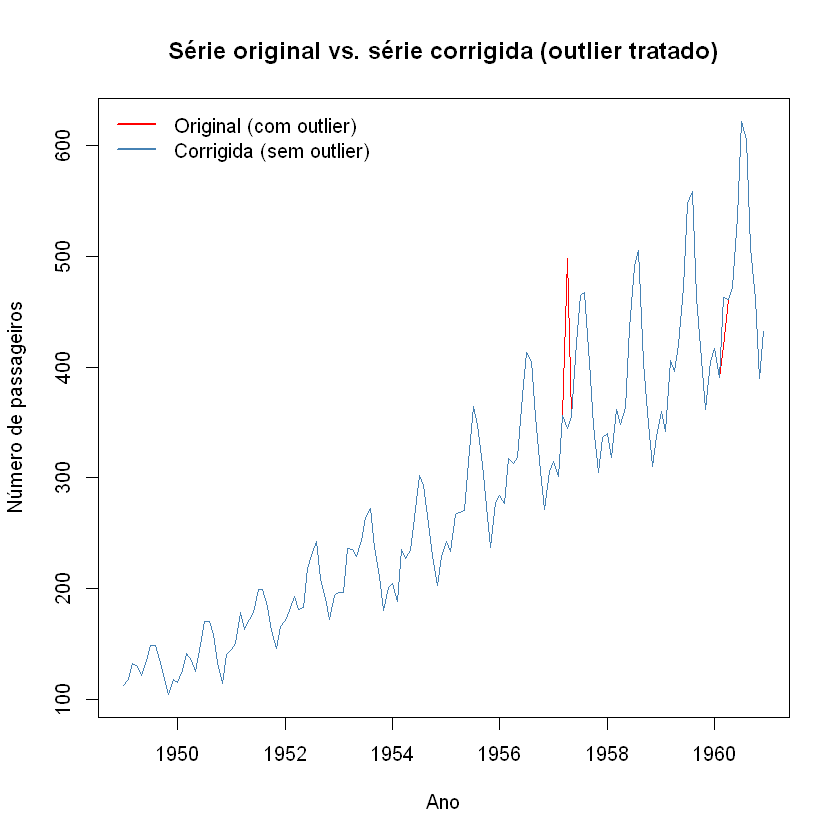

In [20]:
# Série com o efeito do outlier removido (segundo o modelo de intervenção estimado)
y_adj <- deteccao$yadj

# Comparando visualmente a série original (com outlier) e a série corrigida
plot(y, main = "Série original vs. série corrigida (outlier tratado)",
     ylab = "Número de passageiros", xlab = "Ano", col = "red", lwd = 1.5)
lines(y_adj, col = "steelblue", lwd = 1.5)
legend("topleft", legend = c("Original (com outlier)", "Corrigida (sem outlier)"),
       col = c("red", "steelblue"), lwd = 2, bty = "n")

No gráfico, as duas séries são praticamente idênticas em todos os pontos, exceto exatamente na posição do outlier, onde a série corrigida (azul) volta a acompanhar o padrão sazonal esperado, enquanto a série original (vermelha) mostra o salto artificial.

Agora reajustamos o mesmo modelo, $\text{SARIMA}(0,1,1)(0,1,1)_{12}$, sobre a série corrigida.

In [21]:
lambda_adj <- BoxCox.lambda(y_adj)

fit_adj <- Arima(y_adj, order = c(0, 1, 1),
                  seasonal = list(order = c(0, 1, 1), period = 12),
                  lambda = lambda_adj)
summary(fit_adj)

Series: y_adj 
ARIMA(0,1,1)(0,1,1)[12] 
Box Cox transformation: lambda= -0.2864374 

Coefficients:
          ma1     sma1
      -0.4022  -0.5992
s.e.   0.0929   0.0729

sigma^2 = 5.977e-05:  log likelihood = 450.11
AIC=-894.23   AICc=-894.04   BIC=-885.6

Training set error measures:
                     ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.5142541 9.255744 7.036503 -0.1307846 2.609958 0.2174208
                   ACF1
Training set 0.03108008

In [36]:
#outrojeito
AO100 <- rep(0, length(y))
AO135 <- rep(0, length(y))

AO100[100] <- 1
AO135[135] <- 1

xreg <- cbind(AO100, AO135)
fit_adj <- Arima(
  y,
  order = c(0,1,1),
  seasonal = list(order = c(0,1,1), period = 12),
  xreg = xreg,
  lambda = lambda
)
summary(fit_adj)


Series: y 
Regression with ARIMA(0,1,1)(0,1,1)[12] errors 
Box Cox transformation: lambda= -0.3203622 

Coefficients:
          ma1     sma1   AO100    AO135
      -0.4030  -0.5950  0.0523  -0.0156
s.e.   0.0935   0.0733  0.0048   0.0054

sigma^2 = 4.291e-05:  log likelihood = 473.08
AIC=-936.15   AICc=-935.67   BIC=-921.78

Training set error measures:
                     ME    RMSE      MAE       MPE     MAPE      MASE
Training set -0.6063763 9.32866 7.057657 -0.150354 2.623412 0.2057444
                   ACF1
Training set 0.03938314


	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,1)(0,1,1)[12] errors
Q* = 27.326, df = 22, p-value = 0.1991

Model df: 2.   Total lags used: 24



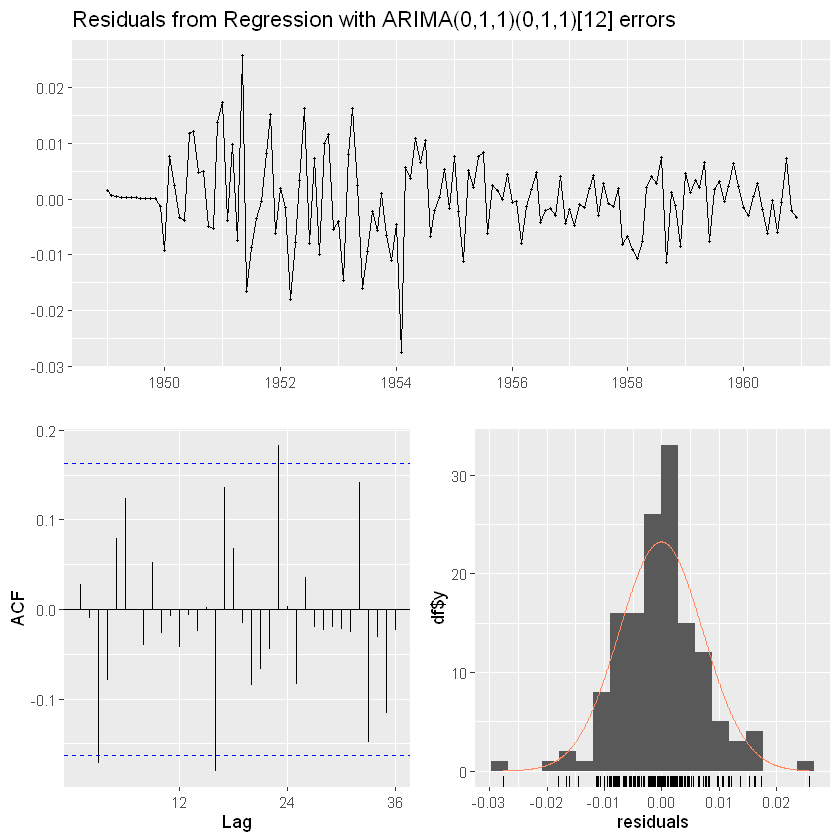

In [34]:
checkresiduals(fit_adj)

In [35]:
# Teste de normalidade dos resíduos
shapiro.test(residuals(fit_adj))


	Shapiro-Wilk normality test

data:  residuals(fit_adj)
W = 0.97921, p-value = 0.02751


**Interpretação:**

* Após o tratamento do outlier, o gráfico de resíduos ao longo do tempo **não apresenta mais o pico isolado** que víamos antes -- os resíduos ficam mais homogêneos, sem o salto pontual em torno da observação 100.
* O teste de Ljung-Box e o exame do ACF dos resíduos devem indicar comportamento mais próximo de ruído branco, e o teste de Shapiro-Wilk tende a mostrar **maior aderência à normalidade** do que no modelo ajustado sobre a série com outlier.
* Os critérios de informação (AIC/BIC) do modelo `fit_adj` também tendem a melhorar (ficar menores), já que o modelo não precisa mais "absorver" parte da variância extra causada pelo outlier.

**Conclusão da Etapa 9:** o tratamento do outlier melhora a qualidade do ajuste e a validade dos pressupostos do modelo, sem alterar a especificação SARIMA escolhida -- apenas os dados de entrada foram corrigidos.

---
## Etapa 10: Comparando as previsões antes e depois do tratamento

Por fim, comparamos as previsões dos próximos 12 meses obtidas com o modelo ajustado sobre a série **original (com outlier)** e sobre a série **corrigida (sem outlier)**.

In [24]:
fc_adj <- forecast(fit_adj, h = 12, level = c(80, 95))

# Comparação lado a lado das previsões pontuais
comparacao <- cbind(
  Previsao_com_outlier    = as.numeric(fc$mean),
  Previsao_sem_outlier    = as.numeric(fc_adj$mean),
  Diferenca               = as.numeric(fc$mean) - as.numeric(fc_adj$mean)
)
rownames(comparacao) <- as.character(time(fc$mean))
round(comparacao, 2)

,Previsao_com_outlier,Previsao_sem_outlier,Diferenca
1961,453.75,451.90,1.84
1961.08333333334,431.19,426.47,4.72
1961.16666666667,499.17,507.03,-7.86
1961.25,523.36,496.87,26.49
1961.33333333334,518.64,514.87,3.77
1961.41666666667,606.63,597.39,9.23
1961.5,702.39,691.89,10.50
1961.58333333334,700.83,689.38,11.45
1961.66666666667,580.77,570.32,10.45
1961.75,506.25,502.25,4.00


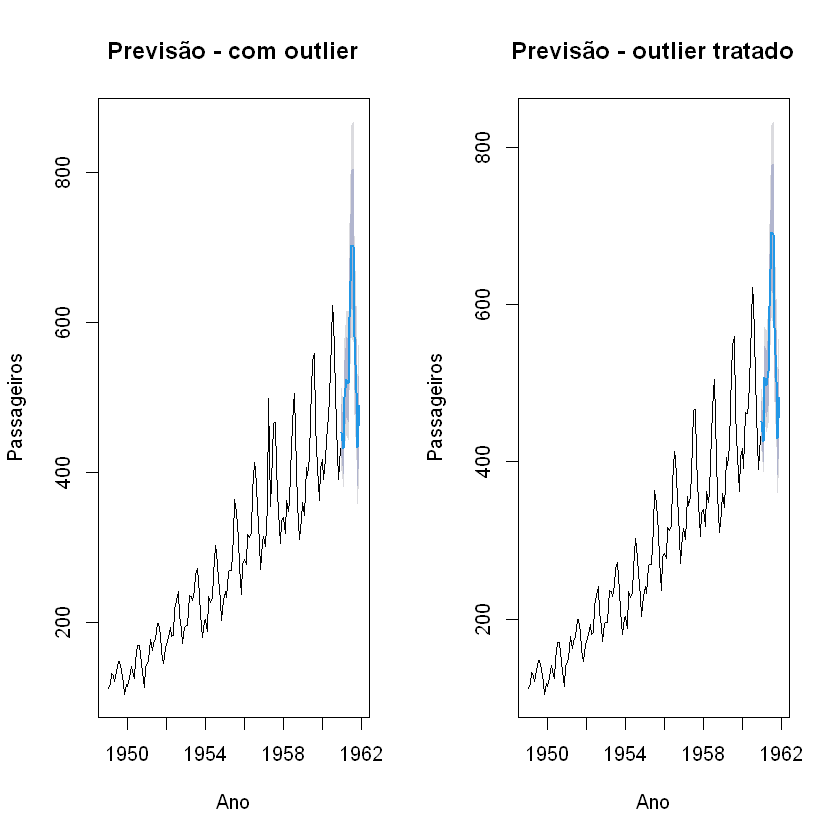

In [25]:
# Comparação visual das duas previsões, lado a lado
par(mfrow = c(1, 2))
plot(fc,     main = "Previsão - com outlier",    ylab = "Passageiros", xlab = "Ano")
plot(fc_adj, main = "Previsão - outlier tratado", ylab = "Passageiros", xlab = "Ano")
par(mfrow = c(1, 1))

In [26]:
# Comparando a amplitude dos intervalos de confiança de 95%
amplitude_com    <- fc$upper[, "95%"]    - fc$lower[, "95%"]
amplitude_semout <- fc_adj$upper[, "95%"] - fc_adj$lower[, "95%"]

cbind(Amplitude_com_outlier = as.numeric(amplitude_com),
      Amplitude_sem_outlier = as.numeric(amplitude_semout))

Amplitude_com_outlier,Amplitude_sem_outlier
110.4961,79.10279
111.8493,85.60834
145.4819,120.36909
164.6192,129.03352
171.7558,146.42457
222.1628,190.19533
282.4065,244.49813
293.5564,257.11113
237.6330,211.46547
205.1975,187.73101


**Interpretação final:**

* As previsões **pontuais** (a média prevista) dos dois modelos tendem a ficar muito próximas, já que o outlier afeta apenas uma observação isolada, longe do fim da série, e o componente MA(1) tem memória curta -- ou seja, seu efeito sobre o *nível* previsto é pequeno.
* A diferença mais importante aparece na **amplitude dos intervalos de confiança**: como o modelo ajustado sobre a série com outlier superestima a variância do erro (por causa do resíduo anormalmente grande na observação 100), seus **intervalos de previsão tendem a ser mais largos** do que os do modelo ajustado sobre a série corrigida.
* Isso ilustra um ponto importante em séries temporais: mesmo quando um outlier pontual não desloca muito a previsão central, ele pode **inflar a incerteza estimada** e comprometer a interpretação prática dos intervalos de confiança -- daí a importância das Etapas 8 e 9.

---

## Conclusão geral

A série `AirPassengers` (com outlier artificial) apresenta tendência de crescimento e forte sazonalidade multiplicativa, tratadas respectivamente por diferenciação não sazonal ($d=1$) e sazonal ($D=1$) após transformação logarítmica. O modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ -- o clássico *airline model* -- se ajusta bem à série, mas o diagnóstico de resíduos revela a presença de um valor atípico do tipo *additive outlier* na observação 100. Após identificar e tratar esse outlier, o modelo reajustado apresenta resíduos mais próximos de ruído branco e intervalos de previsão mais estreitos e confiáveis, embora as previsões pontuais permaneçam praticamente inalteradas.